Day1 : Dataset Understanding

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
##pip install tensorflow[and-cuda]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:00<00:00, 208MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


In [6]:
print(os.listdir(path))

['metadata_rgb_only.csv', 'Brain Tumor Data Set', 'metadata.csv']


In [7]:
path1=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set")
print(os.listdir(path1))

['Healthy', 'Brain Tumor']


In [8]:
images_path=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Brain Tumor")
print(images_path)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [9]:
print(len(os.listdir(images_path)))
print(os.listdir(images_path)[:5])

2513
['Cancer (7).jpg', 'Cancer (2319).jpg', 'Cancer (3).jpg', 'Cancer (471).jpg', 'Cancer (1592).jpg']


In [10]:
import pandas as pd
import os

data = []

folder_name = "Brain Tumor"
count = len(os.listdir(images_path))

data.append((folder_name, count))

print(f"{folder_name}: {count} images")

df = pd.DataFrame(data, columns=["Class", "Count"])
df

Brain Tumor: 2513 images


,Class,Count
0,Brain Tumor,2513


In [11]:
images_pathhealthy=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Healthy")
print(images_pathhealthy)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Healthy


In [12]:
print(len(os.listdir(images_pathhealthy)))
print(os.listdir(images_pathhealthy)[:5])

2087
['Not Cancer  (1702).jpg', 'Not Cancer  (693).jpg', 'Not Cancer  (1022).jpg', 'Not Cancer  (744).jpg', 'Not Cancer  (374).jpg']


In [13]:
import pandas as pd
import os

data = []

# Brain Tumor
tumor_images = [img for img in os.listdir(images_path) if img.endswith(('.jpg', '.png', '.tif'))]
tumor_count = len(tumor_images)
data.append(("Brain Tumor", tumor_count))

print(f"Brain Tumor: {tumor_count} images")

# Healthy
healthy_images = [img for img in os.listdir(images_pathhealthy) if img.endswith(('.jpg', '.png', '.tif'))]
healthy_count = len(healthy_images)
data.append(("Healthy", healthy_count))

print(f"Healthy: {healthy_count} images")


# Create DataFrame
df = pd.DataFrame(data, columns=["Class", "Count"])

df

Brain Tumor: 2445 images
Healthy: 2075 images


,Class,Count
0,Brain Tumor,2445
1,Healthy,2075


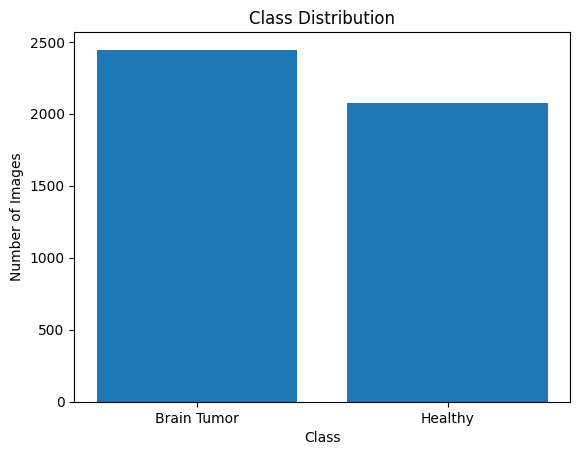

In [14]:
plt.bar(df["Class"], df["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [15]:
from PIL import Image
import os

sizes = []

# Brain Tumor images
for img_name in os.listdir(images_path)[:50]:  # sample
    img_path = os.path.join(images_path, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

# Healthy images
for img_name in os.listdir(images_pathhealthy)[:50]:  # sample
    img_path = os.path.join(images_pathhealthy, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

print("Sample Image Sizes:", sizes[:10])

Sample Image Sizes: [(512, 512), (273, 326), (512, 512), (512, 512), (271, 307), (620, 620), (512, 512), (279, 354), (205, 243), (300, 347)]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load one sample image
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))

print("Min pixel value:", img.min())
print("Max pixel value:", img.max())
print("Mean brightness:", img.mean())

Min pixel value: 0
Max pixel value: 255
Mean brightness: 32.78482437133789


In [17]:
brightness_values = []

for img_name in os.listdir(images_path)[:50]:
    img = plt.imread(os.path.join(images_path, img_name))
    brightness_values.append(img.mean())

print("Average brightness:", sum(brightness_values)/len(brightness_values))

Average brightness: 66.43510282678173


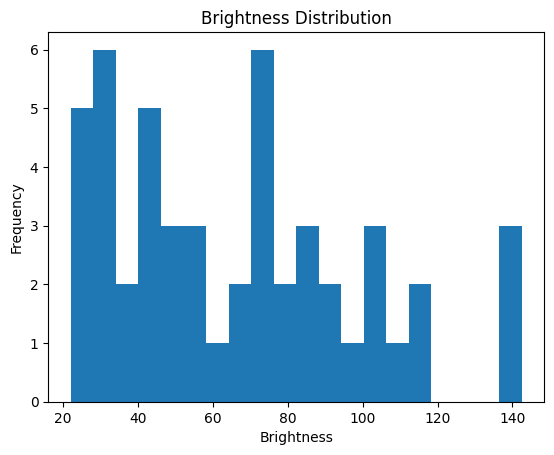

In [18]:
plt.hist(brightness_values, bins=20)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

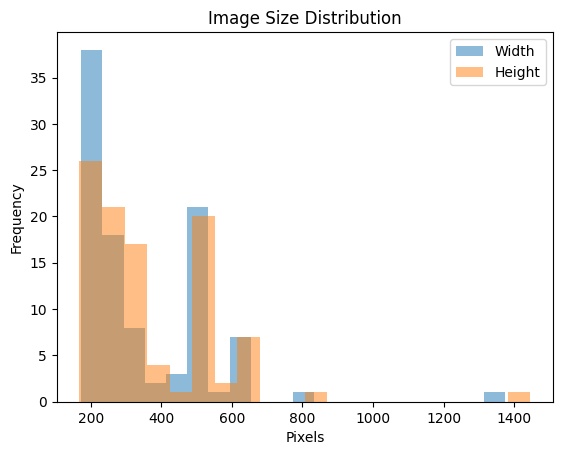

In [19]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.hist(widths, bins=20, alpha=0.5, label='Width')
plt.hist(heights, bins=20, alpha=0.5, label='Height')
plt.legend()
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.show()

In [20]:
import hashlib

hashes = set()
duplicates = 0

for img_name in os.listdir(images_path)[:100]:
    with open(os.path.join(images_path, img_name), 'rb') as f:
        filehash = hashlib.md5(f.read()).hexdigest()
        if filehash in hashes:
            duplicates += 1
        else:
            hashes.add(filehash)

print("Duplicate images:", duplicates)

Duplicate images: 0


In [21]:
df["Percentage"] = (df["Count"] / df["Count"].sum()) * 100
df

,Class,Count,Percentage
0,Brain Tumor,2445,54.09292
1,Healthy,2075,45.90708


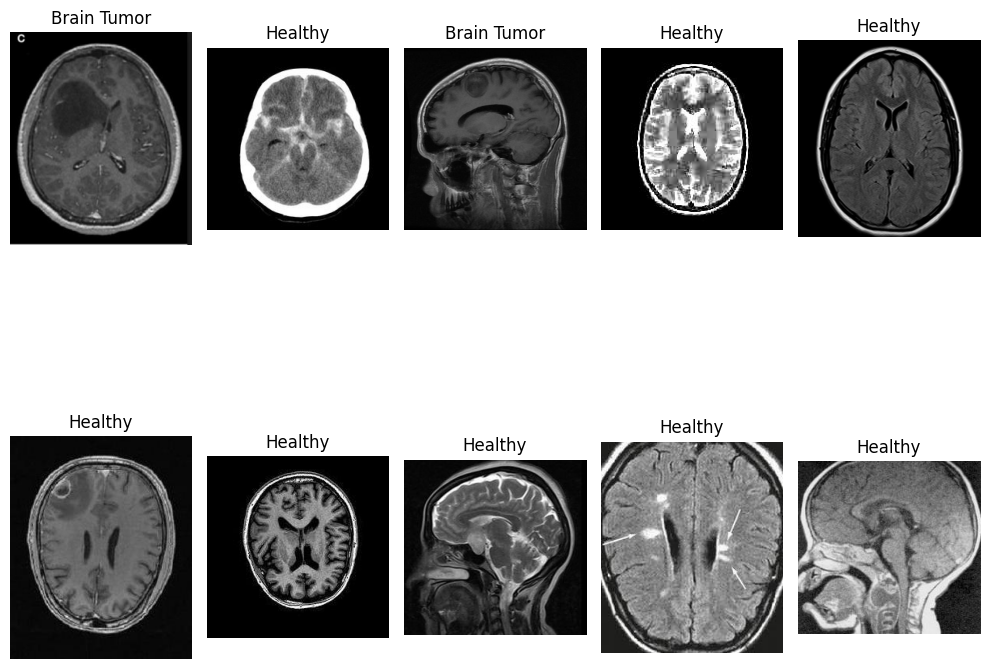

In [22]:
import matplotlib.pyplot as plt
import random
import os

plt.figure(figsize=(10, 10))

for i in range(10):

    # Randomly choose class
    if random.random() > 0.5:
        folder = "Brain Tumor"
        folder_path = images_path
    else:
        folder = "Healthy"
        folder_path = images_pathhealthy

    # Pick random image
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = plt.imread(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image mode:", img.mode)

Image mode: RGB


In [24]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image mode:", img.mode)

Image mode: RGB


In [25]:
from PIL import Image

corrupted = 0

for img_name in os.listdir(images_path):
    try:
        img = Image.open(os.path.join(images_path, img_name))
    except:
        corrupted += 1

print("Corrupted images:", corrupted)

Corrupted images: 0


In [26]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image shape:", img.shape)

Image shape: (512, 512, 3)


In [27]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image shape:", img.shape)

Image shape: (620, 620, 3)


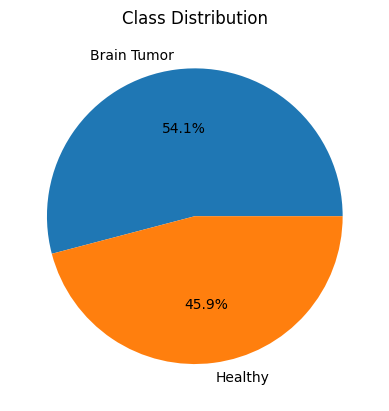

In [28]:
plt.pie(df["Count"], labels=df["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

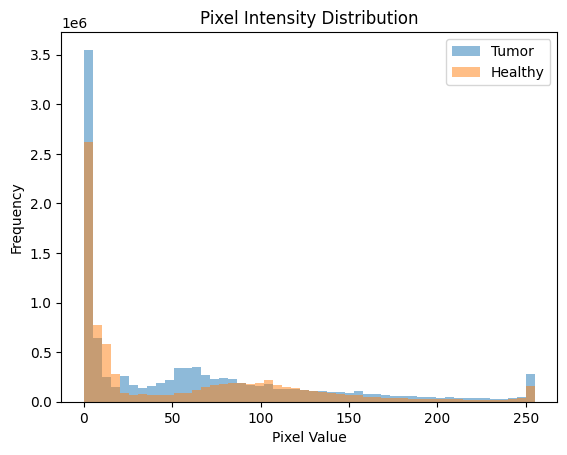

In [29]:
tumor_pixels = []
healthy_pixels = []

# Tumor
for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_pixels.extend(img.flatten())

# Healthy
for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_pixels.extend(img.flatten())

# Plot
plt.hist(tumor_pixels, bins=50, alpha=0.5, label='Tumor')
plt.hist(healthy_pixels, bins=50, alpha=0.5, label='Healthy')
plt.legend()
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [30]:
label_map = {
    "Healthy": 0,
    "Brain Tumor": 1
}

print(label_map)

{'Healthy': 0, 'Brain Tumor': 1}


In [31]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Min pixel:", img.min())
print("Max pixel:", img.max())

Min pixel: 0
Max pixel: 255


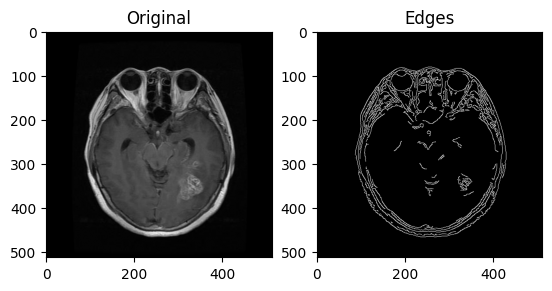

In [32]:
import cv2

img_path = os.path.join(images_path, os.listdir(images_path)[0])
img = cv2.imread(img_path, 0)

edges = cv2.Canny(img, 100, 200)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.show()

/tmp/ipykernel_18339/3694909810.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tumor_mean, healthy_mean], labels=["Tumor", "Healthy"])


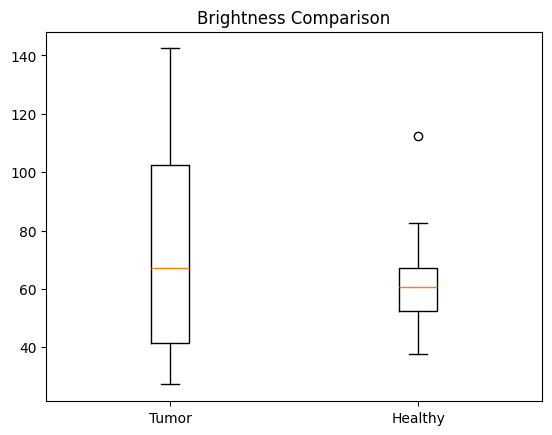

In [33]:
tumor_mean = []
healthy_mean = []

for img_name in os.listdir(images_path)[:20]:
    img = plt.imread(os.path.join(images_path, img_name))
    tumor_mean.append(img.mean())

for img_name in os.listdir(images_pathhealthy)[:20]:
    img = plt.imread(os.path.join(images_pathhealthy, img_name))
    healthy_mean.append(img.mean())

plt.boxplot([tumor_mean, healthy_mean], labels=["Tumor", "Healthy"])
plt.title("Brightness Comparison")
plt.show()


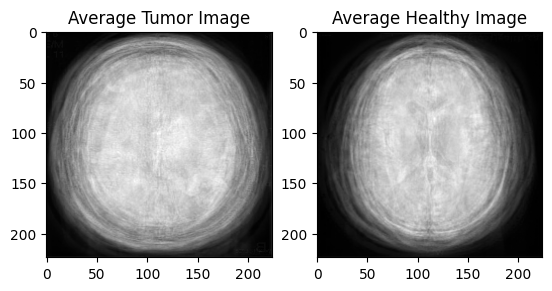

In [34]:
import numpy as np
import cv2

def average_image(folder_path):
    images = []

    for img_name in os.listdir(folder_path)[:50]:
        img = cv2.imread(os.path.join(folder_path, img_name), 0)
        img = cv2.resize(img, (224, 224))
        images.append(img)

    return np.mean(images, axis=0)

tumor_avg = average_image(images_path)
healthy_avg = average_image(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='gray')
plt.title("Average Tumor Image")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='gray')
plt.title("Average Healthy Image")

plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

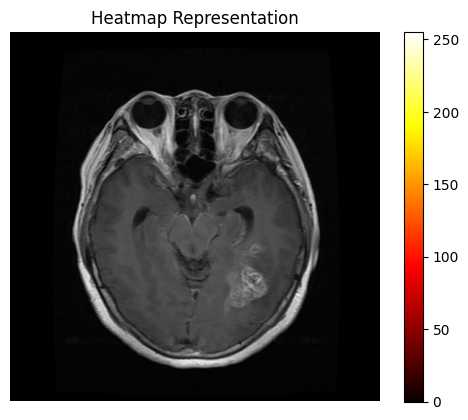

In [35]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
plt.imshow(img, cmap='hot')
plt.colorbar()
plt.title("Heatmap Representation")
plt.axis('off')

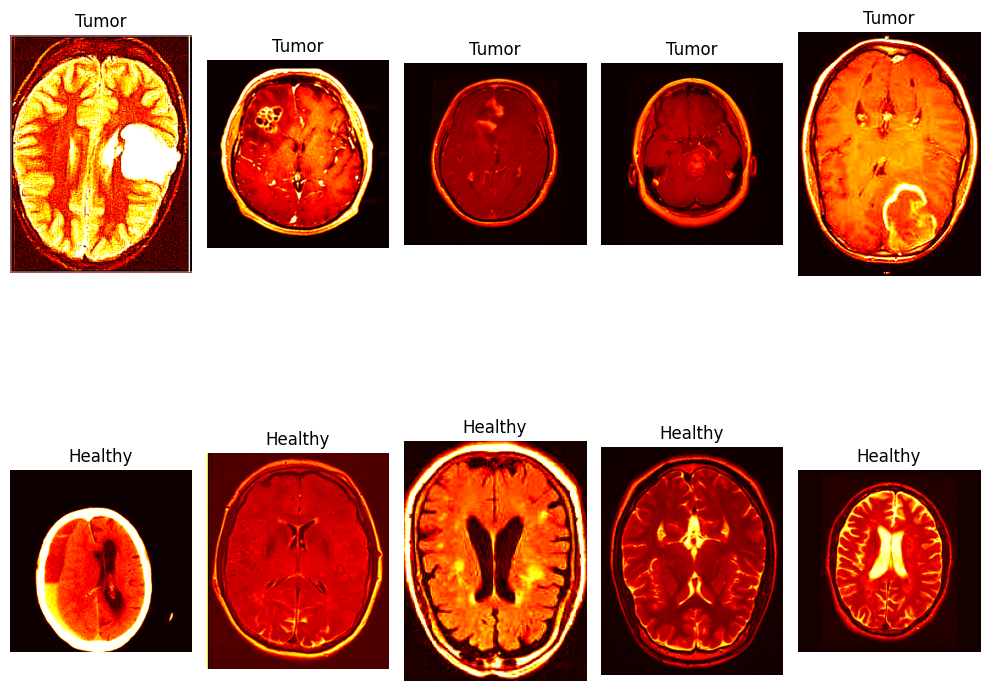

In [36]:
import matplotlib.pyplot as plt
import os
import cv2
import random

plt.figure(figsize=(10, 10))

# Tumor images
for i in range(5):
    img_name = random.choice(os.listdir(images_path))
    img = cv2.imread(os.path.join(images_path, img_name), 0)

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='hot')
    plt.title("Tumor")
    plt.axis('off')

# Healthy images
for i in range(5):
    img_name = random.choice(os.listdir(images_pathhealthy))
    img = cv2.imread(os.path.join(images_pathhealthy, img_name), 0)

    plt.subplot(2, 5, i+6)
    plt.imshow(img, cmap='hot')
    plt.title("Healthy")
    plt.axis('off')

plt.tight_layout()
plt.show()

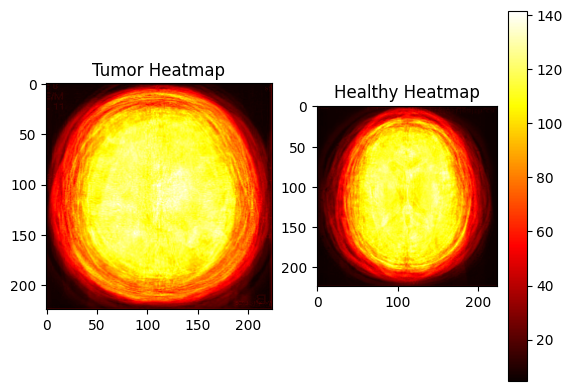

In [37]:
import numpy as np
import cv2

def avg_heatmap(folder):
    imgs = []

    for img_name in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, img_name), 0)
        img = cv2.resize(img, (224, 224))
        imgs.append(img)

    return np.mean(imgs, axis=0)

tumor_avg = avg_heatmap(images_path)
healthy_avg = avg_heatmap(images_pathhealthy)

plt.subplot(1,2,1)
plt.imshow(tumor_avg, cmap='hot')
plt.title("Tumor Heatmap")

plt.subplot(1,2,2)
plt.imshow(healthy_avg, cmap='hot')
plt.title("Healthy Heatmap")

plt.colorbar()
plt.show()

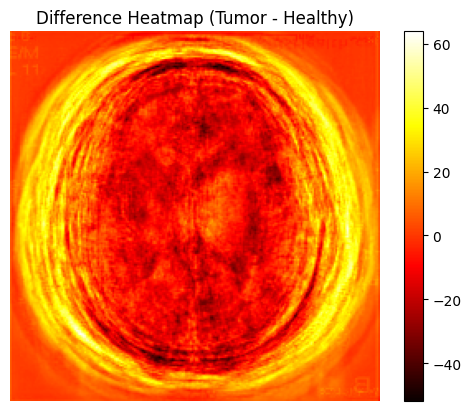

In [38]:
diff = tumor_avg - healthy_avg

plt.imshow(diff, cmap='hot')
plt.colorbar()
plt.title("Difference Heatmap (Tumor - Healthy)")
plt.axis('off')
plt.show()

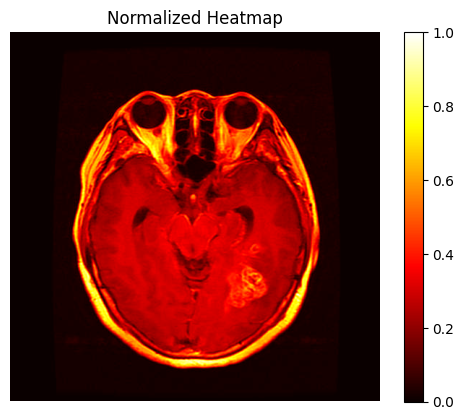

In [39]:
img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

img_norm = img / 255.0

plt.imshow(img_norm, cmap='hot')
plt.colorbar()
plt.title("Normalized Heatmap")
plt.axis('off')
plt.show()

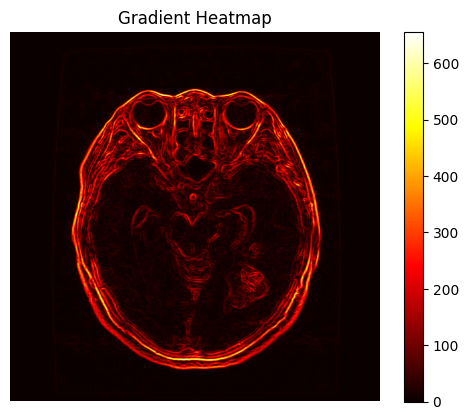

In [40]:
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1)

gradient = np.sqrt(grad_x**2 + grad_y**2)

plt.imshow(gradient, cmap='hot')
plt.colorbar()
plt.title("Gradient Heatmap")
plt.axis('off')
plt.show()

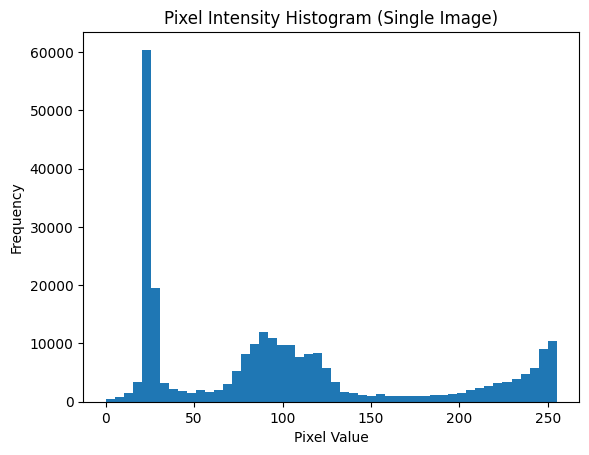

In [41]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[1]))

plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Histogram (Single Image)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

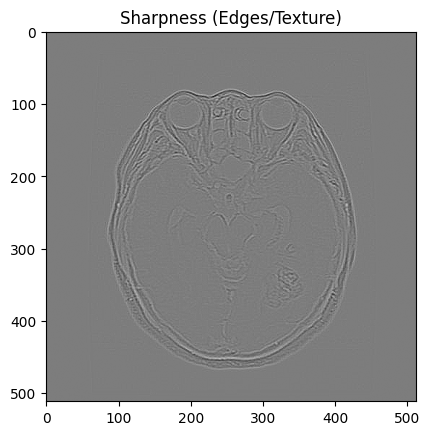

In [42]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

plt.imshow(laplacian, cmap='gray')
plt.title("Sharpness (Edges/Texture)")
plt.show()

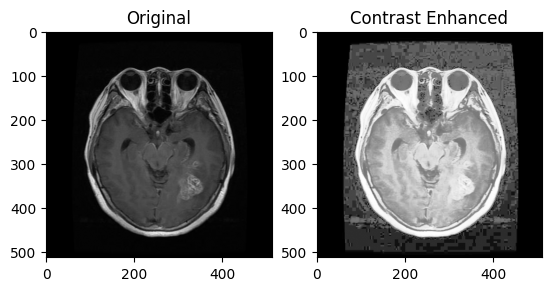

In [43]:
import cv2

img = cv2.imread(os.path.join(images_path, os.listdir(images_path)[0]), 0)

# Increase contrast
contrast = cv2.equalizeHist(img)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Enhanced")

plt.show()

DAY 2 : Data Cleaning & Preprocessing

In [44]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from collections import Counter

In [45]:
CONFIG = {
    "IMG_SIZE": 224,
    "TUMOR_LABEL": 1,
    "HEALTHY_LABEL": 0
}

# 👉 UPDATE THESE PATHS
tumor_path = images_path
healthy_path = images_pathhealthy

In [46]:


def process_images(folder_path, label):
    data = []
    labels = []
    count = 0

    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path, 0)

            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))

            # Normalize
            img = img.astype("float32") / 255.0

            data.append(img)
            labels.append(label)

            count += 1

        except Exception as e:
            print(f"Error processing {img_name}")

    return data, labels, count

In [47]:

print("Processing Tumor Images...")
tumor_data, tumor_labels, tumor_count = process_images(
    tumor_path, CONFIG["TUMOR_LABEL"]
)

print("Processing Healthy Images...")
healthy_data, healthy_labels, healthy_count = process_images(
    healthy_path, CONFIG["HEALTHY_LABEL"]
)

# Combine
data = tumor_data + healthy_data
labels = tumor_labels + healthy_labels

print(f"Tumor count: {tumor_count}")
print(f"Healthy count: {healthy_count}")


Processing Tumor Images...
Processing Healthy Images...
Tumor count: 2513
Healthy count: 2087


In [48]:
class_counts = Counter(labels)
print("Class Distribution:", class_counts)

Class Distribution: Counter({1: 2513, 0: 2087})


In [49]:
X = np.array(data)
y = np.array(labels)

print("Shape before reshape:", X.shape)

Shape before reshape: (4600, 224, 224)


In [50]:
X = X.reshape(-1, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"], 1)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (4600, 224, 224, 1)
Final y shape: (4600,)


In [51]:
X, y = shuffle(X, y, random_state=42)

print("Data shuffled")

Data shuffled


In [52]:
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [53]:
np.savez_compressed("brain_tumor_data.npz", X=X, y=y)

print("Data saved successfully!")

Data saved successfully!


Day 3- Data Pipeline

In [54]:
from sklearn.model_selection import train_test_split

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (3220, 224, 224, 1)
Val: (690, 224, 224, 1)
Test: (690, 224, 224, 1)


In [55]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val   = np.repeat(X_val, 3, axis=-1)
X_test  = np.repeat(X_test, 3, axis=-1)

In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05
)

val_aug = ImageDataGenerator()

In [57]:
train_gen = train_aug.flow(
    X_train, y_train,
    batch_size=32
)

val_gen = val_aug.flow(
    X_val, y_val,
    batch_size=32
)

test_gen = val_aug.flow(
    X_test, y_test,
    batch_size=32,
    shuffle=False
)

In [58]:
images, labels = next(train_gen)

print("Batch shape:", images.shape)
print("Labels:", labels[:5])

Batch shape: (32, 224, 224, 3)
Labels: [1 0 0 1 1]


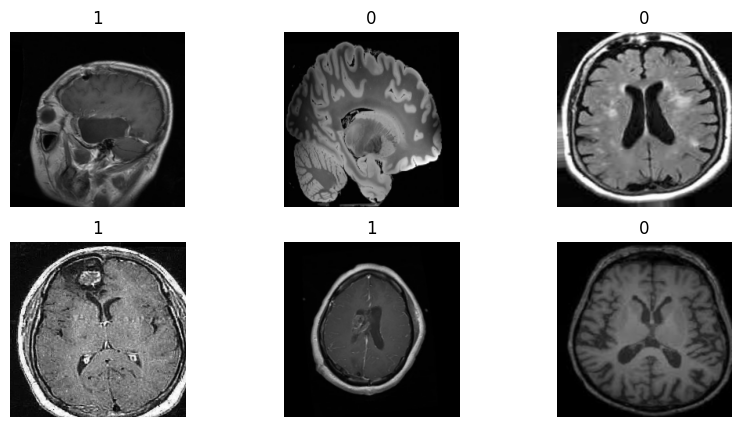

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis('off')
plt.show()

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
